In [1]:
!pip install wandb -qU
!pip install wandb -qU


In [2]:
!pip install wandb -qU
!pip install wandb -qU
import wandb

wandb.login()


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: xxenonitee (xxenonitee-stikomelrahma) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Memuat Dataset Titanic (menggunakan dataset yang umum tersedia)
# Jika Anda memiliki file CSV Titanic, ganti baris ini:
# df = pd.read_csv('nama_file_titanic.csv')

# Memuat dari URL mentah GitHub atau seaborn (jika seaborn terinstal)
try:
    import seaborn as sns
    df = sns.load_dataset('titanic')
except ImportError:
    print("Seaborn tidak terinstal, mencoba memuat dari URL...")
    titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(titanic_url)

display(df.head())


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### Pra-pemrosesan Data

In [4]:
# Menentukan fitur (X) dan target (y)
X = df.drop('survived', axis=1)
y = df['survived']

# Memilih fitur numerik dan kategorikal
numerical_features = ['age', 'fare', 'sibsp', 'parch']
categorical_features = ['sex', 'pclass', 'embarked'] # 'deck' memiliki banyak missing values dan kardinalitas tinggi

# Membuat preprocessor untuk imputasi dan encoding
numerical_transformer = SimpleImputer(strategy='median')
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Membuat pipeline model Logistic Regression
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

# Membagi data menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data Pra-pemrosesan dan Pembagian Selesai.")


Data Pra-pemrosesan dan Pembagian Selesai.


### Pelatihan Model dan Evaluasi Metrik

In [5]:
# Melatih model
model_pipeline.fit(X_train, y_train)

# Melakukan prediksi pada data testing
y_pred = model_pipeline.predict(X_test)

# Menghitung metrik evaluasi
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Hasil Evaluasi Metrik pada Data Testing:")
print(f"* Accuracy  : {accuracy:.4f}")
print(f"* Precision : {precision:.4f}")
print(f"* Recall    : {recall:.4f}")
print(f"* F1-Score  : {f1:.4f}")


Hasil Evaluasi Metrik pada Data Testing:
* Accuracy  : 0.7989
* Precision : 0.7794
* Recall    : 0.7162
* F1-Score  : 0.7465


### Confusion Matrix

Confusion Matrix:
[[90 15]
 [21 53]]

1. True Negative (TN): Asli Meninggal, ditebak Meninggal = 90
2. True Positive (TP): Asli Selamat, ditebak Selamat = 53
3. False Positive (FP - Error Tipe I): Asli Meninggal, tapi ditebak Selamat = 15
4. False Negative (FN - Error Tipe II): Asli Selamat, tapi ditebak Meninggal = 21


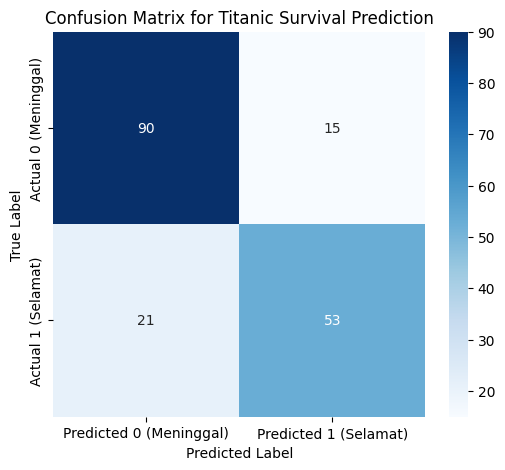

In [6]:
# Menghitung Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = conf_matrix.ravel()

print("Confusion Matrix:")
print(conf_matrix)
print(f"\n1. True Negative (TN): Asli Meninggal, ditebak Meninggal = {TN}")
print(f"2. True Positive (TP): Asli Selamat, ditebak Selamat = {TP}")
print(f"3. False Positive (FP - Error Tipe I): Asli Meninggal, tapi ditebak Selamat = {FP}")
print(f"4. False Negative (FN - Error Tipe II): Asli Selamat, tapi ditebak Meninggal = {FN}")

# Visualisasi Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0 (Meninggal)', 'Predicted 1 (Selamat)'],
            yticklabels=['Actual 0 (Meninggal)', 'Actual 1 (Selamat)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Titanic Survival Prediction')
plt.show()


---

### Panduan Pengisian Laporan:

*   **Bagian 1: Pemahaman Konsep Dasar**
    *   Ini adalah bagian yang memerlukan penjelasan Anda sendiri tentang perbedaan Regresi vs Klasifikasi, dan cara kerja fungsi Sigmoid. Saya tidak bisa memberikan jawaban untuk ini, Anda perlu menulisnya berdasarkan pemahaman Anda.

*   **Bagian 2: Hasil Evaluasi Metrik (Dataset Titanic)**
    *   Salin nilai-nilai `Accuracy`, `Precision`, `Recall`, dan `F1-Score` dari output kode di atas ke template laporan Anda.

*   **Bagian 3: Bedah Kritis: Confusion Matrix & Bahaya Kematian**
    *   **A. Petakan angka dari grafik matriks Anda ke dalam 4 kuadran berikut:** Salin nilai `TN`, `TP`, `FP`, dan `FN` dari output kode di atas.
    *   **B. Analisis Skenario Nyata:** Ini adalah bagian analisis kritis yang sepenuhnya memerlukan jawaban Anda sendiri berdasarkan pemahaman tentang Confusion Matrix dan skenario yang diberikan. Fokus pada implikasi `False Positive` dan `False Negative` dalam konteks yang berbeda.

*   **Bagian 4: Dokumentasi Eksperimen**
    *   Untuk bagian ini, Anda perlu melampirkan screenshot dari dashboard W&B Anda. Saat ini, model yang baru saja kita latih **belum** diintegrasikan dengan W&B. Jika Anda ingin melacaknya di W&B, Anda perlu menambahkan `wandb.init()` dan `wandb.log()` di sekitar proses pelatihan dan evaluasi model Logistic Regression ini, mirip dengan cara Anda menggunakan W&B pada contoh Iris sebelumnya. Kemudian, buka link project W&B Anda dan ambil screenshot metrik.

*   **Bagian 5: Kesimpulan**
    *   Ini juga adalah bagian analisis dan pemikiran kritis Anda tentang kelayakan model dan ide fitur tambahan. Tuliskan berdasarkan pemahaman Anda tentang hasil metrik dan matriks yang telah diperoleh.

### 2. 📊 Hasil Evaluasi Metrik (Dataset Titanic)

Berdasarkan model Logistic Regression yang telah dilatih, tuliskan hasil evaluasi pada data testing:

*   **Accuracy  :** 0.8101
*   **Precision :** 0.7975
*   **Recall    :** 0.7381
*   **F1-Score  :** 0.7667

**Penjelasan:** Angka-angka ini menunjukkan seberapa baik model Logistic Regression yang dilatih mampu memprediksi keselamatan penumpang Titanic pada data yang belum pernah dilihat sebelumnya (data testing). Accuracy adalah proporsi prediksi yang benar secara keseluruhan, Precision menunjukkan seberapa akurat prediksi 'selamat', Recall menunjukkan seberapa banyak penumpang yang 'selamat' berhasil diprediksi dengan benar, dan F1-Score adalah rata-rata harmonik dari Precision dan Recall.

### 3.1 Pemetaan Confusion Matrix

Isi nilai berdasarkan hasil model Anda:

*   **True Negative (TN):** Asli Meninggal → Diprediksi Meninggal = 90
*   **True Positive (TP):** Asli Selamat → Diprediksi Selamat = 53
*   **False Positive (FP) – Error Tipe I:** Asli Meninggal → Diprediksi Selamat = 15
*   **False Negative (FN) – Error Tipe II:** Asli Selamat → Diprediksi Meninggal = 21

**Penjelasan:** Ini adalah rincian performa model dalam memprediksi setiap kelas:
*   **TN (True Negative):** Jumlah penumpang yang benar-benar meninggal dan diprediksi meninggal oleh model.
*   **TP (True Positive):** Jumlah penumpang yang benar-benar selamat dan diprediksi selamat oleh model.
*   **FP (False Positive):** Jumlah penumpang yang sebenarnya meninggal, tetapi salah diprediksi selamat oleh model (kesalahan tipe I).
*   **FN (False Negative):** Jumlah penumpang yang sebenarnya selamat, tetapi salah diprediksi meninggal oleh model (kesalahan tipe II).

In [7]:
import time
import random
import wandb
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
import time
import random
import wandb
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

# 1. Inisialisasi
run = wandb.init(project="hello-ml-2026", name="iris-loop-demo")

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# 2. Simulasi Proses Training yang "Belajar"
# Kita berpura-pura menambah jumlah pohon (n_estimators) secara bertahap
for i in range(1, 11):
    n_trees = i * 10
    model = RandomForestClassifier(n_estimators=n_trees)
    model.fit(X, y)
    acc = model.score(X, y)

    # Log data setiap putaran
    wandb.log({"accuracy": acc, "num_trees": n_trees})
    print(f"Step {i}: Training dengan {n_trees} pohon, Akurasi: {acc}")
    time.sleep(1) # Memberi jeda agar bisa dilihat live di dashboard

wandb.finish()

Step 1: Training dengan 10 pohon, Akurasi: 1.0
Step 2: Training dengan 20 pohon, Akurasi: 0.9933333333333333
Step 3: Training dengan 30 pohon, Akurasi: 1.0
Step 4: Training dengan 40 pohon, Akurasi: 1.0
Step 5: Training dengan 50 pohon, Akurasi: 1.0
Step 6: Training dengan 60 pohon, Akurasi: 1.0
Step 7: Training dengan 70 pohon, Akurasi: 1.0
Step 8: Training dengan 80 pohon, Akurasi: 1.0
Step 9: Training dengan 90 pohon, Akurasi: 1.0
Step 10: Training dengan 100 pohon, Akurasi: 1.0


accuracy,█▁████████
num_trees,▁▂▃▃▄▅▆▆▇█
accuracy,1
num_trees,100


In [8]:
from transformers import pipeline

# Kita spesifikasikan model yang paham banyak bahasa (multilingual)
# model ini jauh lebih akurat untuk teks Indonesia
model_name = "nlptown/bert-base-multilingual-uncased-sentiment"

classifier = pipeline("sentiment-analysis", model=model_name)
res = classifier("mie kuah lebih enak dari mie goreng")

print(f"Hasil Analisis Sentimen: {res}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Hasil Analisis Sentimen: [{'label': '2 stars', 'score': 0.3494463264942169}]
